# OSHA Structured Data Preprocessing for Embedding-Based VAE

This notebook preprocesses an OSHA CSV file for a **deep learning based unsupervised pipeline**, specifically an **embedding-based VAE + clustering** approach.

## What this notebook does

It prepares structured OSHA injury data by:

- loading data directly from a CSV file
- selecting relevant structured columns
- handling missing values and noisy categories
- cleaning binary indicators
- grouping rare categories into `Other`
- integer-encoding categorical columns for embedding layers
- creating separate model inputs:
  - `X_cat` for categorical features
  - `X_bin` for binary/numeric features
- saving cleaned data and metadata for later clustering and interpretation

This is designed as the **Step 1 preprocessing stage** before building the VAE.


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

Set the path to your OSHA CSV file and choose preprocessing parameters.


In [ ]:
# -----------------------------
# User configuration
# -----------------------------
CSV_PATH = "January2015toAugust2025.csv"   # Replace with your OSHA CSV path
OUT_DIR = "/content/drive/MyDrive/osha_preprocessed"

MIN_CATEGORY_COUNT = 20
DROP_HIGH_MISSING_THRESHOLD = 0.85
KEEP_NARRATIVE = True


## Load the CSV

This cell reads the OSHA CSV directly and shows a quick overview.


In [ ]:
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw.columns = [str(c).strip() for c in df_raw.columns]

print("Loaded CSV shape:", df_raw.shape)
print("\nFirst 20 columns:")
print(df_raw.columns[:20].tolist())

print("\nPreview:")
display(df_raw.head())


FileNotFoundError: [Errno 2] No such file or directory: 'January2015toAugust2025.csv'

## Missingness overview

This helps identify extra columns and columns with large amounts of missing data.


In [ ]:
missing_frac = df_raw.isna().mean().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_fraction": missing_frac,
    "missing_percent": (missing_frac * 100).round(2)
})

display(missing_summary.head(20))


,missing_fraction,missing_percent
Address2,0.911817,91.18
Inspection,0.663277,66.33
Secondary Source Title,0.533793,53.38
Secondary Source,0.533793,53.38
Longitude,0.000665,0.07
Latitude,0.000665,0.07
Zip,0.000231,0.02
Address1,0.000173,0.02
City,0.000164,0.02
Amputation,0.000067,0.01


## Select columns for the structured VAE pipeline

These are the main columns used for the first version of the model.


In [ ]:
categorical_cols = [
    "Primary NAICS",
    "NatureTitle",
    "Part of Body Title",
    "EventTitle",
    "SourceTitle"
]

binary_cols = [
    "Hospitalized",
    "Amputation",
    "Loss of Eye"
]

optional_cols = [
    "FederalState",
    "EventDate",
    "Final Narrative",
    "ID",
    "UPA"
]

candidate_keep = categorical_cols + binary_cols + optional_cols

existing_cols = [c for c in candidate_keep if c in df_raw.columns]
missing_expected = [c for c in candidate_keep if c not in df_raw.columns]

print("Columns found:")
print(existing_cols)

print("\nExpected columns not found:")
print(missing_expected)


Columns found:
['Primary NAICS', 'NatureTitle', 'Part of Body Title', 'EventTitle', 'SourceTitle', 'Hospitalized', 'Amputation', 'Loss of Eye', 'FederalState', 'EventDate', 'Final Narrative', 'ID', 'UPA']

Expected columns not found:
[]


## Create working dataframe

Only the relevant columns are kept for this stage.


In [ ]:
df = df_raw[[c for c in existing_cols if c in df_raw.columns]].copy()
print("Working dataframe shape:", df.shape)
display(df.head())


Working dataframe shape: (103750, 13)


,Primary NAICS,NatureTitle,Part of Body Title,EventTitle,SourceTitle,Hospitalized,Amputation,Loss of Eye,FederalState,EventDate,Final Narrative,ID,UPA
0,922140,Fractures,Lower leg(s),Injured by physical contact with person while ...,Co-worker,1.0,0.0,0.0,1,1/1/2015,Three correctional facility guards were escort...,2015010015,931176
1,339999,Second degree heat (thermal) burns,"Leg(s), n.e.c.","Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches",1.0,0.0,0.0,1,1/1/2015,Employee in the Machine Shop received second d...,2015010016,930267
2,484121,"Traumatic injuries and disorders, unspecified",Nonclassifiable,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck",1.0,0.0,0.0,1,1/1/2015,A truck driver fell approximately 4 feet while...,2015010018,929823
3,424490,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",Caught in or compressed by equipment or object...,Pallet jack-powered,1.0,0.0,0.0,1,1/1/2015,An employee's leg was pinned between a truck a...,2015010019,929711
4,326122,Fractures,"Finger(s), fingernail(s), n.e.c.",Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi...",1.0,0.0,0.0,1,1/1/2015,An employee working on the Line 6 Auto-Beller ...,2015010020,929642


## Basic type cleanup


In [ ]:
if "ID" in df.columns:
    df["ID"] = df["ID"].astype(str)

if "UPA" in df.columns:
    df["UPA"] = df["UPA"].astype(str)

if "EventDate" in df.columns:
    df["EventDate"] = pd.to_datetime(df["EventDate"], errors="coerce")

df.dtypes


,0
Primary NAICS,object
NatureTitle,object
Part of Body Title,object
EventTitle,object
SourceTitle,object
Hospitalized,float64
Amputation,float64
Loss of Eye,float64
FederalState,int64
EventDate,datetime64[ns]


## Clean binary columns

OSHA CSV exports may store binary fields in different ways, such as:

- `0/1`
- `Yes/No`
- `True/False`
- missing values

This cell normalizes them into clean `0/1` values.


In [ ]:
def clean_binary_series(s):
    mapping = {
        "yes": 1, "y": 1, "true": 1, "1": 1, 1: 1, True: 1,
        "no": 0, "n": 0, "false": 0, "0": 0, 0: 0, False: 0
    }

    s2 = s.copy()
    if s2.dtype == object:
        s2 = s2.astype(str).str.strip().str.lower()
        s2 = s2.replace({"nan": np.nan, "none": np.nan, "": np.nan})

    s2 = s2.map(mapping) if s2.dtype == object else s2
    s2 = pd.to_numeric(s2, errors="coerce")
    s2 = s2.fillna(0).astype(int)
    s2 = s2.clip(0, 1)
    return s2

for col in binary_cols:
    if col in df.columns:
        df[col] = clean_binary_series(df[col])

if "FederalState" in df.columns:
    df["FederalState"] = clean_binary_series(df["FederalState"])

display(df[[c for c in binary_cols if c in df.columns]].head())


,Hospitalized,Amputation,Loss of Eye
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


## Clean categorical columns

For each categorical feature, this notebook:

- fills missing values with `Unknown`
- normalizes blank or null-like strings
- groups rare categories into `Other`

This improves embedding stability and reduces over-fragmentation.


In [ ]:
for col in categorical_cols:
    if col not in df.columns:
        continue

    df[col] = df[col].fillna("Unknown").astype(str).str.strip()

    df[col] = df[col].replace({
        "": "Unknown",
        "nan": "Unknown",
        "None": "Unknown",
        "NONE": "Unknown",
        "null": "Unknown",
        "NULL": "Unknown"
    })

    value_counts = df[col].value_counts(dropna=False)
    rare_values = value_counts[value_counts < MIN_CATEGORY_COUNT].index
    df.loc[df[col].isin(rare_values), col] = "Other"


## Optional narrative cleanup

The narrative is kept only for later multimodal extensions. It is not included in `X_cat` or `X_bin` in this notebook.


In [ ]:
if "Final Narrative" in df.columns:
    df["Final Narrative"] = df["Final Narrative"].fillna("").astype(str).str.strip()

if not KEEP_NARRATIVE and "Final Narrative" in df.columns:
    df = df.drop(columns=["Final Narrative"])

display(df.head())


,Primary NAICS,NatureTitle,Part of Body Title,EventTitle,SourceTitle,Hospitalized,Amputation,Loss of Eye,FederalState,EventDate,Final Narrative,ID,UPA
0,922140,Fractures,Lower leg(s),Injured by physical contact with person while ...,Co-worker,1,0,0,1,2015-01-01,Three correctional facility guards were escort...,2015010015,931176
1,339999,Second degree heat (thermal) burns,"Leg(s), n.e.c.","Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches",1,0,0,1,2015-01-01,Employee in the Machine Shop received second d...,2015010016,930267
2,484121,"Traumatic injuries and disorders, unspecified",Nonclassifiable,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck",1,0,0,1,2015-01-01,A truck driver fell approximately 4 feet while...,2015010018,929823
3,424490,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",Caught in or compressed by equipment or object...,Pallet jack-powered,1,0,0,1,2015-01-01,An employee's leg was pinned between a truck a...,2015010019,929711
4,326122,Fractures,"Finger(s), fingernail(s), n.e.c.",Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi...",1,0,0,1,2015-01-01,An employee working on the Line 6 Auto-Beller ...,2015010020,929642


## Remove problematic rows

This step removes rows missing core structured information after cleanup.


In [ ]:
core_present_cols = [c for c in categorical_cols if c in df.columns]

if len(core_present_cols) > 0:
    df = df.dropna(subset=core_present_cols).reset_index(drop=True)

print("Shape after row cleanup:", df.shape)


Shape after row cleanup: (103750, 13)


## Inspect category sizes after cleanup


In [ ]:
for col in categorical_cols:
    if col in df.columns:
        print(f"\nTop categories for {col}:")
        display(df[col].value_counts().head(10))



Top categories for Primary NAICS:


,count
Primary NAICS,
Other,4181
622110,2407
445110,2069
238210,1926
236220,1919
213112,1871
237310,1550
491110,1536
493110,1534



Top categories for NatureTitle:


,count
NatureTitle,
Fractures,34030
Amputations,23449
"Soreness, pain, hurt-nonspecified injury",6522
"Cuts, lacerations",4267
"Amputations, avulsions, enucleations unspecified",2542
"Intracranial injuries, unspecified",1799
"Traumatic injuries and disorders, unspecified",1729
"Heat (thermal) burns, unspecified",1726
Crushing injuries,1723



Top categories for Part of Body Title:


,count
Part of Body Title,
Fingertip(s),10402
"Finger(s), fingernail(s), n.e.c.",8236
"Finger(s), fingernail(s), unspecified",6821
"Multiple body parts, n.e.c.",5184
BODY SYSTEMS,4887
"Leg(s), unspecified",4131
Hip(s),3739
Nonclassifiable,3720
Brain,3588



Top categories for EventTitle:


,count
EventTitle,
Caught in running equipment or machinery during regular operation,6694
"Other fall to lower level, unspecified",5921
"Caught in running equipment or machinery during maintenance, cleaning",5298
Compressed or pinched by shifting objects or equipment,4985
Fall on same level due to slipping,3681
Other fall to lower level less than 6 feet,3310
Fall on same level due to tripping over an object,2660
Struck against moving part of machinery or equipment,2235
Exposure to environmental heat,2196



Top categories for SourceTitle:


,count
SourceTitle,
Other,5989
"Floor, n.e.c.",5035
"Forklift, order picker, platform truck-powered",3869
Nonclassifiable,2780
"Floors, walkways, ground surfaces, unspecified",2433
Heat-environmental,2197
Other constructed surface,1697
"Machinery, unspecified",1625
Step ladders,1393


## Integer-encode categorical columns for embeddings

Each categorical column gets its own label encoder, because each feature will later use a separate embedding layer.


In [ ]:
X_cat_list = []
feature_info = {
    "categorical": {},
    "binary": [],
    "notes": {
        "min_category_count": MIN_CATEGORY_COUNT,
        "drop_high_missing_threshold": DROP_HIGH_MISSING_THRESHOLD
    }
}

for col in categorical_cols:
    if col not in df.columns:
        continue

    le = LabelEncoder()
    encoded = le.fit_transform(df[col])

    df[col + "_idx"] = encoded
    X_cat_list.append(encoded.reshape(-1, 1))

    feature_info["categorical"][col] = {
        "vocab_size": int(len(le.classes_)),
        "classes": le.classes_.tolist(),
        "index_to_label": {int(i): cls for i, cls in enumerate(le.classes_)},
        "label_to_index": {cls: int(i) for i, cls in enumerate(le.classes_)}
    }

X_cat = np.hstack(X_cat_list) if X_cat_list else np.empty((len(df), 0), dtype=np.int64)

print("X_cat shape:", X_cat.shape)
X_cat[:5]


X_cat shape: (103750, 5)


array([[655,  38,  75, 124, 114],
       [375,  99,  72, 108, 597],
       [475, 116,  99, 164, 474],
       [414, 102,  73,   7, 370],
       [189,  38,  31,   8, 327]])

## Build binary / numeric matrix


In [ ]:
model_binary_cols = [c for c in binary_cols if c in df.columns]

if "FederalState" in df.columns:
    model_binary_cols.append("FederalState")

X_bin = (
    df[model_binary_cols].astype(np.float32).values
    if model_binary_cols
    else np.empty((len(df), 0), dtype=np.float32)
)

feature_info["binary"] = model_binary_cols

print("X_bin shape:", X_bin.shape)
X_bin[:5]


X_bin shape: (103750, 4)


array([[1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.]], dtype=float32)

## Save processed outputs

This saves:

- cleaned CSV
- `X_cat.npy`
- `X_bin.npy`
- `feature_info.json`
- `summary.json`


In [ ]:
out_dir = Path(OUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(out_dir / "osha_cleaned.csv", index=False)
np.save(out_dir / "X_cat.npy", X_cat)
np.save(out_dir / "X_bin.npy", X_bin)

missing_frac = df_raw.isna().mean().sort_values(ascending=False)

summary = {
    "n_rows": int(len(df)),
    "n_categorical_features": int(X_cat.shape[1]),
    "n_binary_features": int(X_bin.shape[1]),
    "categorical_columns_used": list(feature_info["categorical"].keys()),
    "binary_columns_used": model_binary_cols,
    "dropped_high_missing_columns_from_raw": missing_frac[missing_frac > DROP_HIGH_MISSING_THRESHOLD].index.tolist()
}

with open(out_dir / "feature_info.json", "w", encoding="utf-8") as f:
    json.dump(feature_info, f, indent=2)

with open(out_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved outputs to:", out_dir.resolve())


Saved outputs to: /content/drive/MyDrive/osha_preprocessed


## Final sanity checks


In [ ]:
print("Final dataframe shape:", df.shape)
print("X_cat shape:", X_cat.shape)
print("X_bin shape:", X_bin.shape)

print("\nCategorical columns used:")
print(list(feature_info["categorical"].keys()))

print("\nBinary columns used:")
print(feature_info["binary"])

display(df.head())


Final dataframe shape: (103750, 18)
X_cat shape: (103750, 5)
X_bin shape: (103750, 4)

Categorical columns used:
['Primary NAICS', 'NatureTitle', 'Part of Body Title', 'EventTitle', 'SourceTitle']

Binary columns used:
['Hospitalized', 'Amputation', 'Loss of Eye', 'FederalState']


,Primary NAICS,NatureTitle,Part of Body Title,EventTitle,SourceTitle,Hospitalized,Amputation,Loss of Eye,FederalState,EventDate,Final Narrative,ID,UPA,Primary NAICS_idx,NatureTitle_idx,Part of Body Title_idx,EventTitle_idx,SourceTitle_idx
0,922140,Fractures,Lower leg(s),Injured by physical contact with person while ...,Co-worker,1,0,0,1,2015-01-01,Three correctional facility guards were escort...,2015010015,931176,655,38,75,124,114
1,339999,Second degree heat (thermal) burns,"Leg(s), n.e.c.","Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches",1,0,0,1,2015-01-01,Employee in the Machine Shop received second d...,2015010016,930267,375,99,72,108,597
2,484121,"Traumatic injuries and disorders, unspecified",Nonclassifiable,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck",1,0,0,1,2015-01-01,A truck driver fell approximately 4 feet while...,2015010018,929823,475,116,99,164,474
3,424490,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",Caught in or compressed by equipment or object...,Pallet jack-powered,1,0,0,1,2015-01-01,An employee's leg was pinned between a truck a...,2015010019,929711,414,102,73,7,370
4,326122,Fractures,"Finger(s), fingernail(s), n.e.c.",Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi...",1,0,0,1,2015-01-01,An employee working on the Line 6 Auto-Beller ...,2015010020,929642,189,38,31,8,327


## Notes for the next step

This notebook only handles **structured preprocessing**.

The next modeling step is to build an **embedding-based VAE** that:

- takes `X_cat` as categorical feature indices
- takes `X_bin` as binary inputs
- learns a latent representation
- supports clustering in latent space

Later, text narratives can be added using a multimodal extension.


# Step 2: Build an Embedding-Based VAE for OSHA Structured Data

This section builds a Variational Autoencoder for structured OSHA injury records.

## Model idea

Each OSHA record contains:

- categorical features:
  - Primary NAICS
  - NatureTitle
  - Part of Body Title
  - EventTitle
  - SourceTitle
- binary features:
  - Hospitalized
  - Amputation
  - Loss of Eye
  - optionally FederalState

The model will:

1. embed each categorical feature separately
2. concatenate embeddings with binary inputs
3. encode into a latent distribution
4. sample a latent vector
5. reconstruct the original structured record

## Why this design

This lets the model learn nonlinear latent injury archetypes while preserving the semantics of each feature type.

In [ ]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [ ]:
# -----------------------------
# Configuration
# -----------------------------
DATA_DIR = Path("/content/drive/MyDrive/osha_preprocessed")

BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

LATENT_DIM = 16
HIDDEN_DIMS = [128, 64]

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

BETA_START = 0.0
BETA_END = 1.0
BETA_WARMUP_EPOCHS = 15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
# Load outputs from preprocessing notebook
X_cat = np.load(DATA_DIR / "X_cat.npy")
X_bin = np.load(DATA_DIR / "X_bin.npy")

with open(DATA_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

df_clean = pd.read_csv(DATA_DIR / "osha_cleaned.csv")

print("X_cat shape:", X_cat.shape)
print("X_bin shape:", X_bin.shape)
print("Cleaned dataframe shape:", df_clean.shape)

categorical_cols = list(feature_info["categorical"].keys())
binary_cols = feature_info["binary"]

vocab_sizes = [feature_info["categorical"][col]["vocab_size"] for col in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Binary columns:", binary_cols)
print("Vocab sizes:", vocab_sizes)

X_cat shape: (103750, 5)
X_bin shape: (103750, 4)
Cleaned dataframe shape: (103750, 18)
Categorical columns: ['Primary NAICS', 'NatureTitle', 'Part of Body Title', 'EventTitle', 'SourceTitle']
Binary columns: ['Hospitalized', 'Amputation', 'Loss of Eye', 'FederalState']
Vocab sizes: [665, 122, 135, 274, 610]


## Choose embedding dimensions

A common heuristic for categorical embeddings is:

\[
\text{emb\_dim} = \min(50, \lceil \sqrt{\text{vocab\_size}} \rceil + 1)
\]

This keeps embedding layers compact while still expressive enough for learning structure.

In [ ]:
def choose_embedding_dim(vocab_size):
    return min(50, int(math.ceil(math.sqrt(vocab_size))) + 1)

embedding_dims = [choose_embedding_dim(v) for v in vocab_sizes]

embedding_config = list(zip(categorical_cols, vocab_sizes, embedding_dims))
embedding_config

[('Primary NAICS', 665, 27),
 ('NatureTitle', 122, 13),
 ('Part of Body Title', 135, 13),
 ('EventTitle', 274, 18),
 ('SourceTitle', 610, 26)]

In [ ]:
class OSHATabularDataset(Dataset):
    def __init__(self, X_cat, X_bin):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_bin = torch.tensor(X_bin, dtype=torch.float32)

    def __len__(self):
        return len(self.X_cat)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_bin[idx]


dataset = OSHATabularDataset(X_cat, X_bin)
len(dataset)

103750

In [ ]:
n_total = len(dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_set))
print("Val size:", len(val_set))
print("Test size:", len(test_set))

Train size: 83000
Val size: 10375
Test size: 10375


## VAE architecture

The model uses:

- one embedding layer per categorical feature
- concatenation of all embeddings plus binary inputs
- encoder MLP
- latent mean and log-variance
- decoder MLP
- separate reconstruction heads:
  - one head per categorical feature
  - one binary head for numeric/binary outputs

In [ ]:
class OSHAEmbeddingVAE(nn.Module):
    def __init__(self, vocab_sizes, embedding_dims, num_binary, hidden_dims, latent_dim):
        super().__init__()

        self.vocab_sizes = vocab_sizes
        self.embedding_dims = embedding_dims
        self.num_binary = num_binary
        self.latent_dim = latent_dim

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, emb_dim)
            for vocab_size, emb_dim in zip(vocab_sizes, embedding_dims)
        ])

        input_dim = sum(embedding_dims) + num_binary

        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.1))
            prev_dim = h
        self.encoder = nn.Sequential(*encoder_layers)

        self.fc_mu = nn.Linear(prev_dim, latent_dim)
        self.fc_logvar = nn.Linear(prev_dim, latent_dim)

        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Dropout(0.1))
            prev_dim = h
        self.decoder = nn.Sequential(*decoder_layers)

        # Output heads
        self.cat_heads = nn.ModuleList([
            nn.Linear(prev_dim, vocab_size) for vocab_size in vocab_sizes
        ])
        self.bin_head = nn.Linear(prev_dim, num_binary) if num_binary > 0 else None

    def encode_inputs(self, x_cat, x_bin):
        embedded = []
        for i, emb_layer in enumerate(self.embeddings):
            embedded.append(emb_layer(x_cat[:, i]))
        x = torch.cat(embedded + [x_bin], dim=1) if self.num_binary > 0 else torch.cat(embedded, dim=1)
        return x

    def encode(self, x_cat, x_bin):
        x = self.encode_inputs(x_cat, x_bin)
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder(z)
        cat_logits = [head(h) for head in self.cat_heads]
        bin_logits = self.bin_head(h) if self.bin_head is not None else None
        return cat_logits, bin_logits

    def forward(self, x_cat, x_bin):
        mu, logvar = self.encode(x_cat, x_bin)
        z = self.reparameterize(mu, logvar)
        cat_logits, bin_logits = self.decode(z)
        return cat_logits, bin_logits, mu, logvar, z

In [ ]:
model = OSHAEmbeddingVAE(
    vocab_sizes=vocab_sizes,
    embedding_dims=embedding_dims,
    num_binary=X_bin.shape[1],
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM
).to(DEVICE)

model

OSHAEmbeddingVAE(
  (embeddings): ModuleList(
    (0): Embedding(665, 27)
    (1): Embedding(122, 13)
    (2): Embedding(135, 13)
    (3): Embedding(274, 18)
    (4): Embedding(610, 26)
  )
  (encoder): Sequential(
    (0): Linear(in_features=101, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (cat_heads): ModuleList(
    (0): Linear(in_features=128, out_features=665, bias=True)
    (1): Linear(in_features=128, out_features=122, bias=True)
    (2): 

In [ ]:
def vae_loss_function(cat_logits, bin_logits, x_cat, x_bin, mu, logvar, beta=1.0):
    # Categorical reconstruction loss
    cat_loss = 0.0
    for i, logits in enumerate(cat_logits):
        cat_loss = cat_loss + F.cross_entropy(logits, x_cat[:, i], reduction="sum")

    # Binary reconstruction loss
    if bin_logits is not None and x_bin.shape[1] > 0:
        bin_loss = F.binary_cross_entropy_with_logits(bin_logits, x_bin, reduction="sum")
    else:
        bin_loss = torch.tensor(0.0, device=x_cat.device)

    recon_loss = cat_loss + bin_loss

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
def get_beta(epoch, beta_start=BETA_START, beta_end=BETA_END, warmup_epochs=BETA_WARMUP_EPOCHS):
    if epoch >= warmup_epochs:
        return beta_end
    return beta_start + (beta_end - beta_start) * (epoch / warmup_epochs)

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [ ]:
def run_epoch(model, loader, optimizer=None, beta=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum = 0.0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for x_cat_batch, x_bin_batch in loader:
            x_cat_batch = x_cat_batch.to(DEVICE)
            x_bin_batch = x_bin_batch.to(DEVICE)

            cat_logits, bin_logits, mu, logvar, z = model(x_cat_batch, x_bin_batch)
            loss, recon_loss, kl_loss = vae_loss_function(
                cat_logits, bin_logits, x_cat_batch, x_bin_batch, mu, logvar, beta=beta
            )

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            batch_size = x_cat_batch.size(0)
            total_samples += batch_size
            total_loss_sum += loss.item()
            recon_loss_sum += recon_loss.item()
            kl_loss_sum += kl_loss.item()

    return {
        "loss": total_loss_sum / total_samples,
        "recon": recon_loss_sum / total_samples,
        "kl": kl_loss_sum / total_samples
    }

In [ ]:
history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
    "beta": []
}

best_val_loss = float("inf")
best_model_path = DATA_DIR / "best_osha_embedding_vae.pt"

for epoch in range(1, EPOCHS + 1):
    beta = get_beta(epoch - 1)
    history["beta"].append(beta)

    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, beta=beta)
    val_metrics = run_epoch(model, val_loader, optimizer=None, beta=beta)

    history["train_loss"].append(train_metrics["loss"])
    history["train_recon"].append(train_metrics["recon"])
    history["train_kl"].append(train_metrics["kl"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_recon"].append(val_metrics["recon"])
    history["val_kl"].append(val_metrics["kl"])

    print(
        f"Epoch {epoch:03d} | "
        f"beta={beta:.3f} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"train_recon={train_metrics['recon']:.4f} | "
        f"val_recon={val_metrics['recon']:.4f} | "
        f"train_kl={train_metrics['kl']:.4f} | "
        f"val_kl={val_metrics['kl']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        torch.save(model.state_dict(), best_model_path)

print("Best validation loss:", best_val_loss)
print("Best model saved to:", best_model_path)

Epoch 001 | beta=0.000 | train_loss=19.9949 | val_loss=15.2138 | train_recon=19.9949 | val_recon=15.2138 | train_kl=61.9536 | val_kl=112.1392
Epoch 002 | beta=0.067 | train_loss=16.6254 | val_loss=14.7129 | train_recon=15.3426 | val_recon=13.5899 | train_kl=19.2428 | val_kl=16.8441
Epoch 003 | beta=0.133 | train_loss=15.9136 | val_loss=14.6004 | train_recon=14.1564 | val_recon=12.8937 | train_kl=13.1789 | val_kl=12.8001
Epoch 004 | beta=0.200 | train_loss=15.8641 | val_loss=14.6965 | train_recon=13.6524 | val_recon=12.5252 | train_kl=11.0584 | val_kl=10.8569
Epoch 005 | beta=0.267 | train_loss=15.9929 | val_loss=14.9576 | train_recon=13.3834 | val_recon=12.4694 | train_kl=9.7855 | val_kl=9.3307
Epoch 006 | beta=0.333 | train_loss=16.2527 | val_loss=15.2130 | train_recon=13.2892 | val_recon=12.3076 | train_kl=8.8905 | val_kl=8.7163
Epoch 007 | beta=0.400 | train_loss=16.5092 | val_loss=15.5671 | train_recon=13.2193 | val_recon=12.3318 | train_kl=8.2249 | val_kl=8.0884
Epoch 008 | beta=0

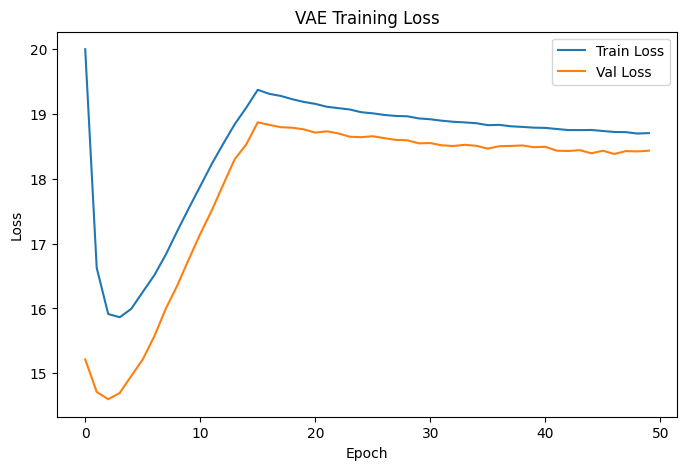

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print("Loaded best model.")

Loaded best model.


In [ ]:
def extract_latent_vectors(model, X_cat, X_bin, batch_size=512):
    dataset = OSHATabularDataset(X_cat, X_bin)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_mu = []
    all_z = []

    model.eval()
    with torch.no_grad():
        for x_cat_batch, x_bin_batch in loader:
            x_cat_batch = x_cat_batch.to(DEVICE)
            x_bin_batch = x_bin_batch.to(DEVICE)

            mu, logvar = model.encode(x_cat_batch, x_bin_batch)
            z = model.reparameterize(mu, logvar)

            all_mu.append(mu.cpu().numpy())
            all_z.append(z.cpu().numpy())

    latent_mu = np.vstack(all_mu)
    latent_z = np.vstack(all_z)
    return latent_mu, latent_z

latent_mu, latent_z = extract_latent_vectors(model, X_cat, X_bin)

print("latent_mu shape:", latent_mu.shape)
print("latent_z shape:", latent_z.shape)

latent_mu shape: (103750, 16)
latent_z shape: (103750, 16)


# Step 3: Cluster in latent space

We now cluster the learned latent representations.

For stability and interpretability, it is usually better to cluster on the latent mean `mu` rather than sampled `z`.

In [ ]:
BEST_K = 8   # you can change this manually (try 4–8)

print(f"Running KMeans with k={BEST_K}...")

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(latent_mu)

df_clustered = df_clean.copy()
df_clustered["cluster"] = cluster_labels

print("Clustering done.")

Running KMeans with k=8...
Clustering done.


In [ ]:
cluster_counts = df_clustered["cluster"].value_counts().sort_index()
print("Cluster sizes:\n")
print(cluster_counts)

Cluster sizes:

cluster
0    14871
1    14256
2     7133
3    13983
4    11439
5    16513
6    12148
7    13407
Name: count, dtype: int64


In [ ]:
for cluster_id in sorted(df_clustered["cluster"].unique()):
    print("\n" + "="*50)
    print(f"CLUSTER {cluster_id}")
    print("="*50)

    sub = df_clustered[df_clustered["cluster"] == cluster_id]

    print(f"\nSize: {len(sub)}")

    # Top categorical features
    for col in categorical_cols:
        if col in sub.columns:
            print(f"\nTop {col}:")
            print(sub[col].value_counts(normalize=True).head(5))

    # Severity
    severity_cols = [c for c in ["Hospitalized", "Amputation", "Loss of Eye"] if c in sub.columns]

    if severity_cols:
        print("\nSeverity rates:")
        print(sub[severity_cols].mean())


CLUSTER 0

Size: 14871

Top Primary NAICS:
Primary NAICS
238160    0.064084
236220    0.035774
238210    0.035438
Other     0.034362
238220    0.030059
Name: proportion, dtype: float64

Top NatureTitle:
NatureTitle
Fractures                                                     0.639970
Soreness, pain, hurt-nonspecified injury                      0.089772
Traumatic injuries and disorders, unspecified                 0.053124
Intracranial injuries, unspecified                            0.037254
Internal injuries to organs and blood vessels of the trunk    0.029588
Name: proportion, dtype: float64

Top Part of Body Title:
Part of Body Title
Multiple body parts, n.e.c.                                 0.157152
Nonclassifiable                                             0.093471
Leg(s), unspecified                                         0.082577
Chest, except internal location of diseases or disorders    0.061664
Ankle(s)                                                    0.057024
Name: p

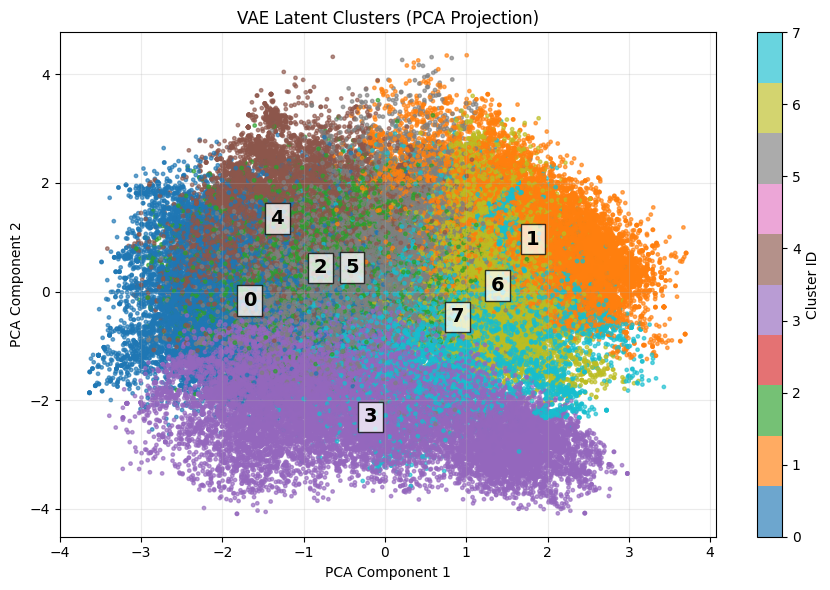

In [ ]:

# PCA projection
latent_2d = PCA(n_components=2, random_state=42).fit_transform(latent_mu)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=6,
    alpha=0.65
)

# Add cluster ID labels at cluster centers
for cluster_id in sorted(np.unique(cluster_labels)):
    points = latent_2d[cluster_labels == cluster_id]
    center_x = points[:, 0].mean()
    center_y = points[:, 1].mean()

    plt.text(
        center_x,
        center_y,
        str(cluster_id),
        fontsize=14,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

plt.title("VAE Latent Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# =============================
# FAST Baseline KMeans (no heavy metrics)
# =============================

from pathlib import Path
import json
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import MiniBatchKMeans  # faster than KMeans

# -----------------------------
# Load from SAME saved location
# -----------------------------
DATA_DIR = Path("/content/drive/MyDrive/osha_preprocessed")

df_clean = pd.read_csv(DATA_DIR / "osha_cleaned.csv")

with open(DATA_DIR / "feature_info.json", "r") as f:
    feature_info = json.load(f)

categorical_cols = list(feature_info["categorical"].keys())
binary_cols = feature_info["binary"]

print("Loaded:", df_clean.shape)

# -----------------------------
# Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

# -----------------------------
# FAST KMeans
# -----------------------------
kmeans = MiniBatchKMeans(
    n_clusters=8,
    batch_size=2048,
    random_state=42
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("kmeans", kmeans)
])

# -----------------------------
# Fit
# -----------------------------
pipeline.fit(df_clean)

labels = pipeline.named_steps["kmeans"].labels_

df_clean["cluster_kmeans_raw"] = labels

# -----------------------------
# Cluster sizes (FAST insight)
# -----------------------------
print("\nCluster sizes:")
print(df_clean["cluster_kmeans_raw"].value_counts().sort_index())

# -----------------------------
# QUICK interpretation (lightweight)
# -----------------------------
for i in range(8):
    print(f"\n===== Cluster {i} =====")
    sub = df_clean[df_clean["cluster_kmeans_raw"] == i]

    print("Size:", len(sub))

    print("\nTop Nature:")
    print(sub["NatureTitle"].value_counts().head(3))

    print("\nTop Event:")
    print(sub["EventTitle"].value_counts().head(3))

# -----------------------------
# Save results
# -----------------------------
df_clean.to_csv(DATA_DIR / "kmeans_baseline_fast.csv", index=False)

print("\nSaved to:", DATA_DIR / "kmeans_baseline_fast.csv")

Loaded: (103750, 18)

Cluster sizes:
cluster_kmeans_raw
0    32969
1    16190
2    25252
3    10205
4     4873
5     6508
6     6287
7     1466
Name: count, dtype: int64

===== Cluster 0 =====
Size: 32969

Top Nature:
NatureTitle
Fractures    32969
Name: count, dtype: int64

Top Event:
EventTitle
Other fall to lower level, unspecified        3387
Fall on same level due to slipping            2413
Other fall to lower level less than 6 feet    2065
Name: count, dtype: int64

===== Cluster 1 =====
Size: 16190

Top Nature:
NatureTitle
Amputations                                          13153
Amputations, avulsions, enucleations  unspecified     1984
Amputations involving bone loss                        829
Name: count, dtype: int64

Top Event:
EventTitle
Caught in running equipment or machinery during regular operation        2919
Caught in running equipment or machinery during maintenance, cleaning    2246
Compressed or pinched by shifting objects or equipment                   1736
Nam

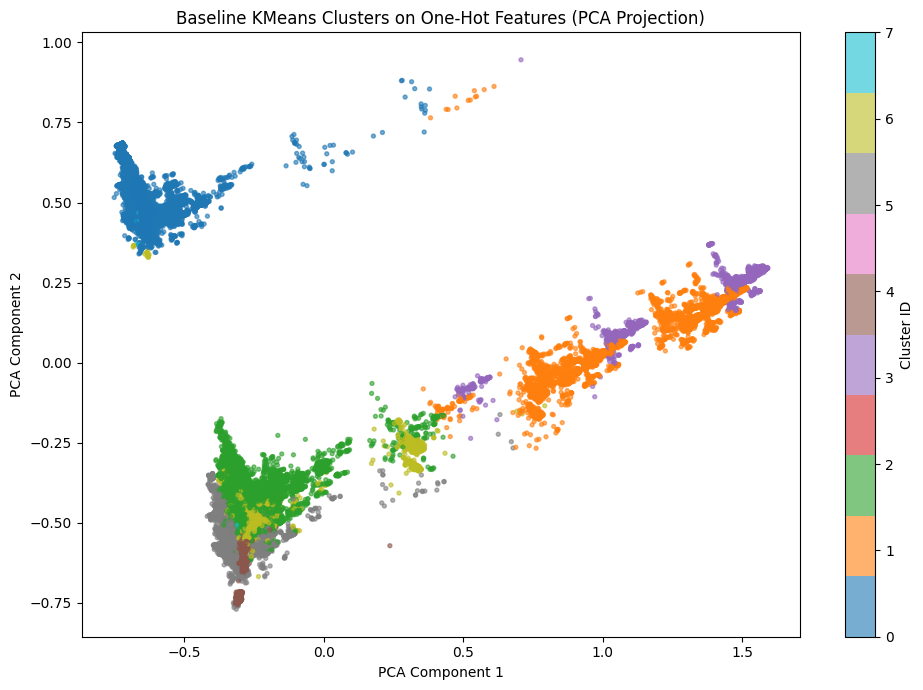

Saved to: /content/drive/MyDrive/osha_preprocessed/baseline_kmeans_pca_clusters.png


In [ ]:
# =============================
# Plot Baseline KMeans Clusters
# like VAE cluster plot
# =============================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

DATA_DIR = Path("/content/drive/MyDrive/osha_preprocessed")

# Load baseline clustered data
df_plot = pd.read_csv(DATA_DIR / "kmeans_baseline_fast.csv")

# Load feature info
import json
with open(DATA_DIR / "feature_info.json", "r") as f:
    feature_info = json.load(f)

categorical_cols = list(feature_info["categorical"].keys())
binary_cols = feature_info["binary"]

# One-hot encode same raw features used for baseline KMeans
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols)
    ]
)

X_encoded = preprocessor.fit_transform(df_plot)

# PCA to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_encoded.toarray())

# Plot clusters
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_plot["cluster_kmeans_raw"],
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.title("Baseline KMeans Clusters on One-Hot Features (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")

plt.tight_layout()
plt.savefig(DATA_DIR / "baseline_kmeans_pca_clusters.png", dpi=300)
plt.show()

print("Saved to:", DATA_DIR / "baseline_kmeans_pca_clusters.png")